# NLP Assignment: Multilingual Sentiment Analysis

Use the provided Bangla and English datasets to build a sentiment analysis system. Apply and compare multiple text classification models, evaluate their performance using appropriate metrics, and select the best-performing model. Develop a Flask API using the selected model and create a user-friendly interface where users can submit Bangla or English text and view the predicted sentiment. Document the preprocessing steps, model comparisons, evaluation results, and system architecture in a project report.

**Deliverables:** 
* Source code
* Trained model
* Flask API
* User interface
* Project report.


# Import Libraries
Here, I have imported all the necessary libraries to achieve the goal.

In [69]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Part01- "Data Cleaning"
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Part02- "Feature Extraction"
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Part03- "Model Selection, Training and Evaluation"
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Serialization of the Model and Vectorizer
import pickle

# Warning Ignore
import warnings

In [70]:
# ignoring warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Data Cleaning & Preprocessing
In this section I have cleaned the given dataset and preprocessed the datasets for further.

## Load Dataset
Here, I have loaded the dataset and assigned it.

In [4]:
df = pd.read_csv('/kaggle/input/datasets/kingshukdatta18/imdb-dataset-creativeit/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Analyze The Dataset

In [6]:
# shape
df.shape

(50000, 2)

In [15]:
# dataset description
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [9]:
# checking duplocated values
df.duplicated().sum()

np.int64(418)

So, after analysis I can say that the dataset has "50000" rows or record and "2" columns. I can also see that the dataset has about "418" duplicate values. Also there are some unnecessary words and stop words. So, Now the cleaning starts.

## Clean The Dataset
Here, I have started cleaning the dataset by removing unnecessary words, duplicate records and stopwords.

### Create Variable to store stop words

In [19]:
stop_words = set(stopwords.words('english'))

### Clean Text Function
This function is created for removing "HTML" tags, removing punctuations and making every letter into lowercasse.

In [22]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text) # Remove HTML
    text = text.lower()                # Lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation
    return text

### Tokenize and Remove Stopwords
This function is created for tokenizing words.

In [23]:
def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return " ".join(filtered_tokens)

### Applying the functions for cleaning

In [24]:
# create 'cleaned_review' column and store cleaned review
df['cleaned_review'] = df['review'].apply(clean_text)

In [25]:
# create 'final_review' column
df['final_review'] = df['cleaned_review'].apply(tokenize_and_remove_stopwords)

In [26]:
df.head()

,review,sentiment,cleaned_review,final_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming te...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,petter matteis love time money visually stunni...


# Visualization
Here I have visualized the dataset both cleaned and raw state.

## Visualization Review Length (Before Vs After)

In [56]:
# Calculate word counts for raw and cleaned text
df['raw_word_count'] = df['review'].apply(lambda x: len(x.split()))
df['clean_word_count'] = df['final_review'].apply(lambda x: len(str(x).split()))

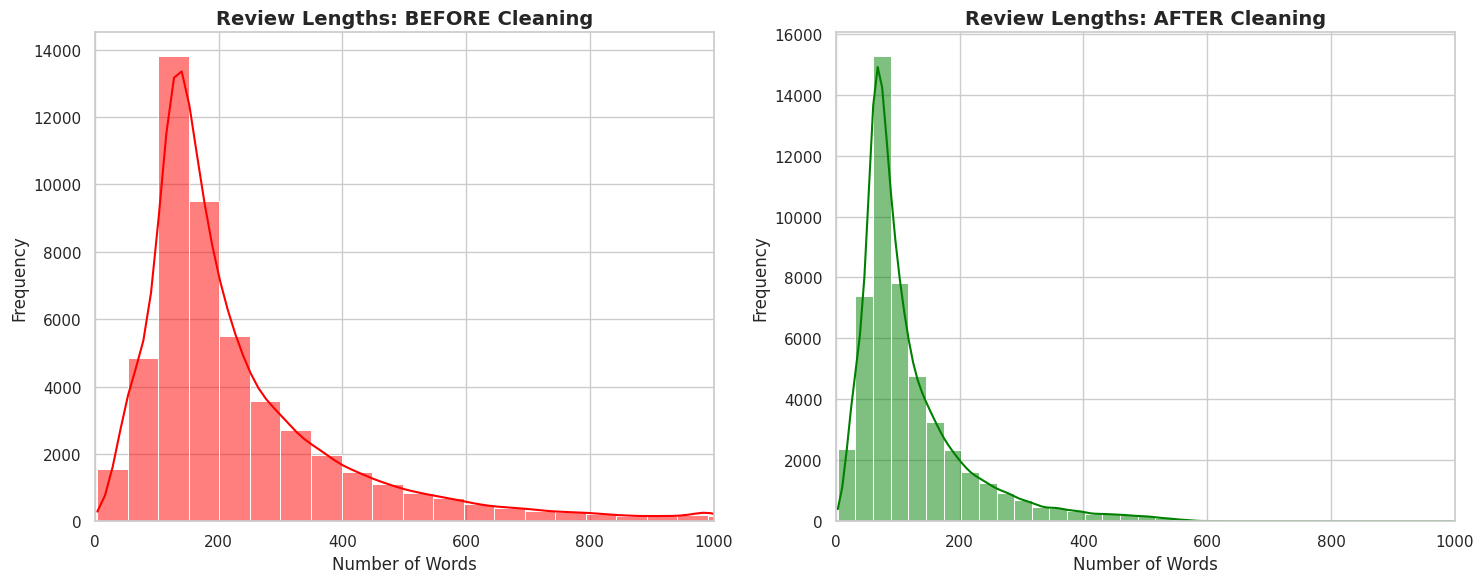

In [63]:
# Set up the plotting area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Plot Raw Data Histogram
sns.histplot(df['raw_word_count'], bins=50, color='red', ax=axes[0], kde=True)
axes[0].set_title('Review Lengths: BEFORE Cleaning', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 1000) # Limiting to 1000 words

# Plot Clean Data Histogram
sns.histplot(df['clean_word_count'], bins=50, color='green', ax=axes[1], kde=True)
axes[1].set_title('Review Lengths: AFTER Cleaning', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

## Generating Word Clouds (Before vs. After)

In [64]:
# Combine all the text into two giant strings
raw_text_combined = " ".join(df['review'].astype(str))
clean_text_combined = " ".join(df['final_review'].astype(str))

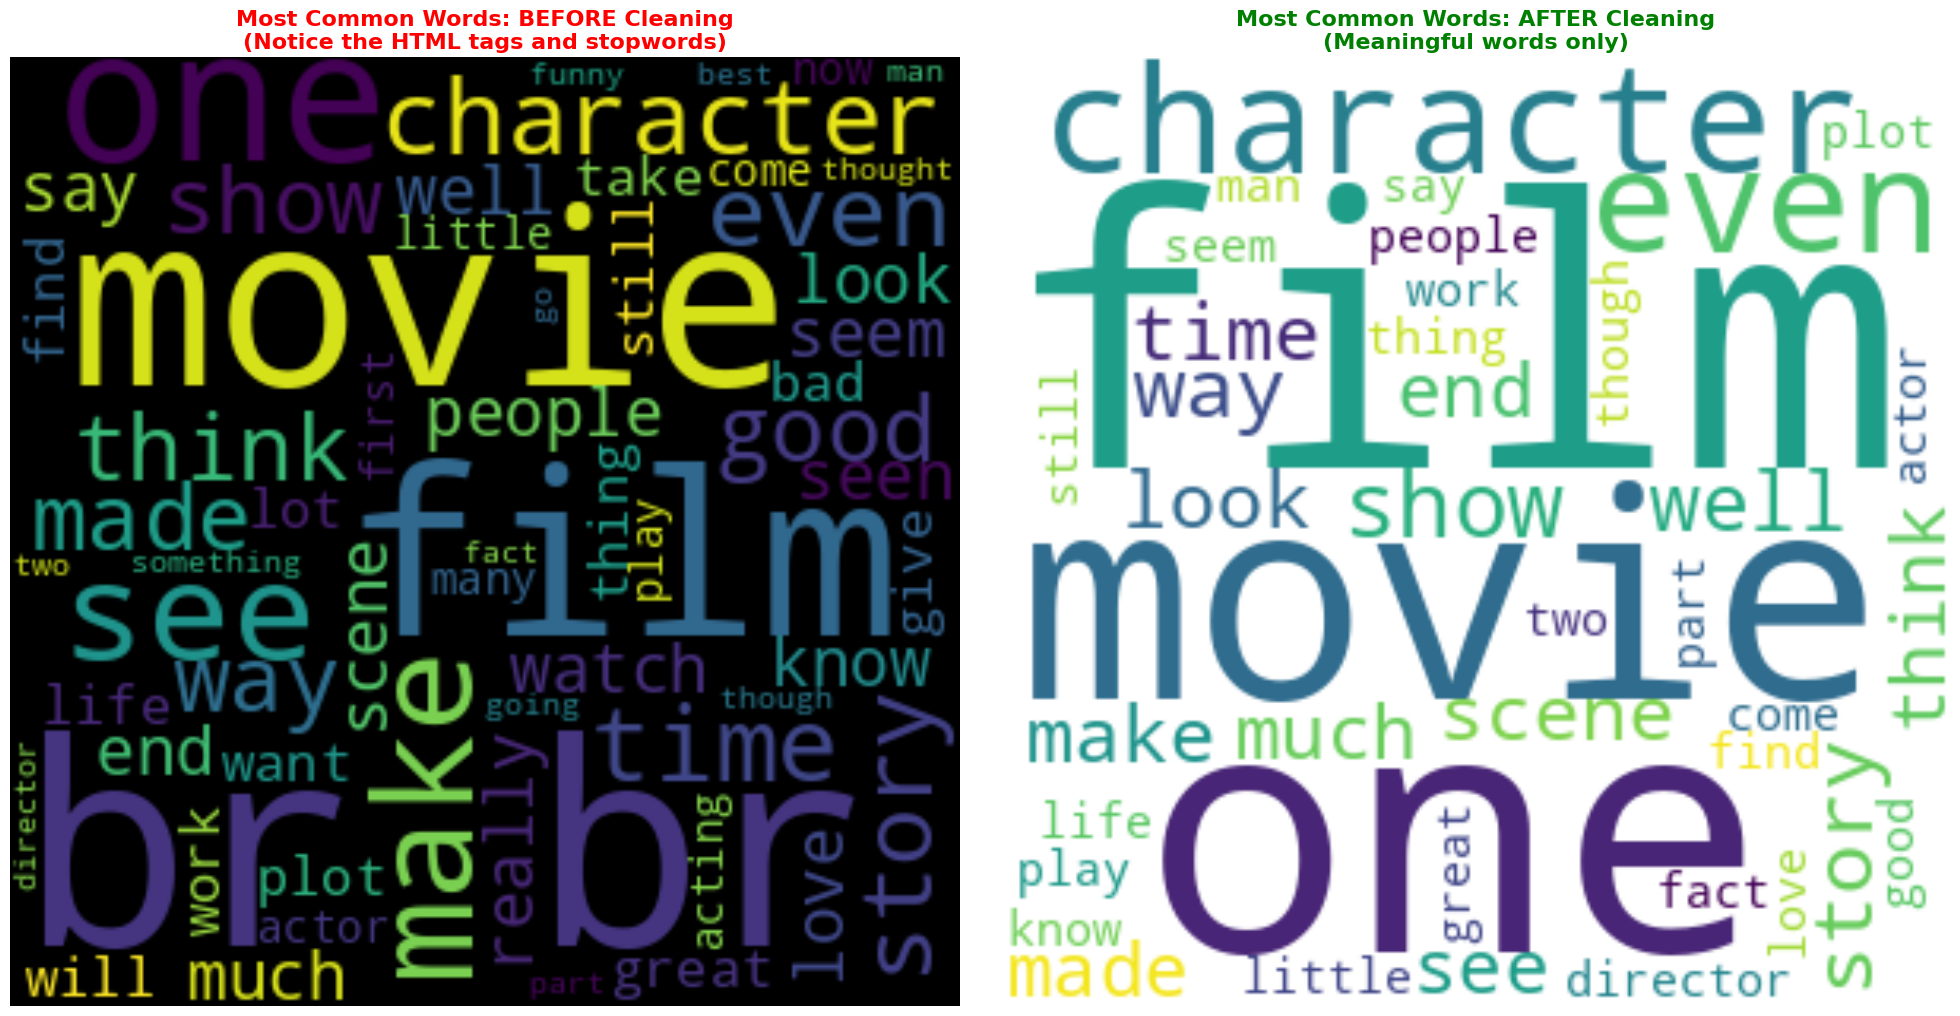

In [67]:
# Set up the plotting area
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Create the BEFORE Word Cloud
wordcloud_raw = WordCloud(width=300, height=300, 
                          background_color='black', 
                          min_font_size=10).generate(raw_text_combined)

axes[0].imshow(wordcloud_raw, interpolation='bilinear')
axes[0].set_title('Most Common Words: BEFORE Cleaning\n(Notice the HTML tags and stopwords)', fontsize=16, fontweight='bold', color='red')
axes[0].axis("off")

# Create the AFTER Word Cloud
wordcloud_clean = WordCloud(width=300, height=300, 
                            background_color='white', 
                            colormap='viridis',
                            min_font_size=10).generate(clean_text_combined)

axes[1].imshow(wordcloud_clean, interpolation='bilinear')
axes[1].set_title('Most Common Words: AFTER Cleaning\n(Meaningful words only)', fontsize=16, fontweight='bold', color='green')
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Visualizing the Class Balance

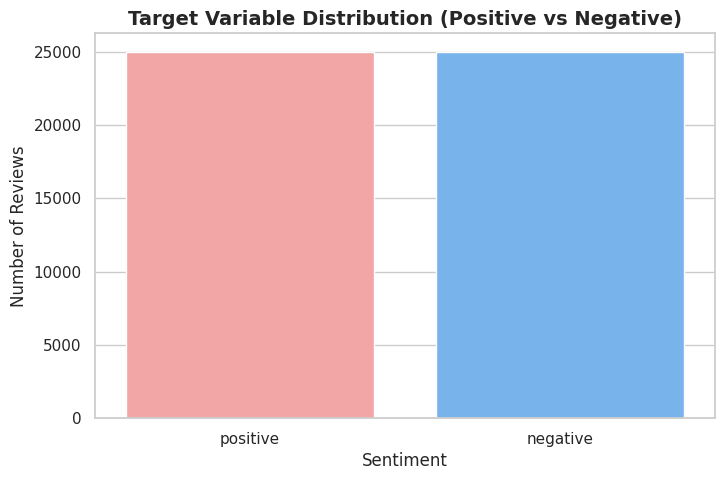

In [71]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', palette=['#ff9999', '#66b3ff'])
plt.title('Target Variable Distribution (Positive vs Negative)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

# Feature Extraction
Here I have Splitted the dataset and created "Count Vectorizer" and "TF-IDF VEctorizer".

## Split the Data
I have splitted the data. For training it is "80%" and for testing it is "20%".

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(
    df['final_review'], 
    df['sentiment'], 
    test_size=0.2, 
    random_state=42
)

## Create the Count Vectorizer
Here, I have created Count  Vectorizer object and fit-transformed.

In [30]:
# creating object for Count Vectorizer and limiting features
count_vectorizer = CountVectorizer(max_features=5000)

In [31]:
# fit and transform
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

## Create the TF-IDF Vectorizer
Here, I have created TF-IDF Vectorizer object and fit-transformed.

In [32]:
# creating object for TF-IDF Vectorizer and limiting features
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

In [33]:
# fit and transformed
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Model Selection, Training and Evaluation
Here, I have evaluated various models to see which model is more suitable for better results. As model have to predict catagorical data, I have selected "Logistic Regression", "Decision Tree" and "K_Nearest Neighbor". I have trained, evaluated and then selected a model.

## 1. Logistic Regression

A statistical model that predicts the probability of a category (such as Yes/No, Spam/Not Spam).

* Uses a mathematical function called the sigmoid function to output probabilities.
* Simple, fast, and easy to interpret.
* Works well when the relationship between features and the target is roughly linear.

**Example:** Predicting whether an email is spam or not.

In [34]:
# creating object
lr_model = LogisticRegression(max_iter=1000, random_state=42)

#### Count Vectorizer- Logistic Regression

In [35]:
lr_model.fit(X_train_count, Y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [36]:
# Checking Score
print("CountVectorizer:")
print(f"  Train Score: {accuracy_score(Y_train, lr_model.predict(X_train_count)):.4f}")
print(f"  Test Score:  {accuracy_score(Y_test, lr_model.predict(X_test_count)):.4f}")

CountVectorizer:
  Train Score: 0.9362
  Test Score:  0.8776


#### TF-IDF VEctorizer- Logistic Regression

In [38]:
lr_model.fit(X_train_tfidf, Y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [39]:
print("TF-IDF Vectorizer:")
print(f"  Train Score: {accuracy_score(Y_train, lr_model.predict(X_train_tfidf)):.4f}")
print(f"  Test Score:  {accuracy_score(Y_test, lr_model.predict(X_test_tfidf)):.4f}\n")

TF-IDF Vectorizer:
  Train Score: 0.9132
  Test Score:  0.8888



## 2. Decision Tree

A model that makes decisions by splitting data into branches based on feature values, forming a tree-like structure.

* Easy to visualize and understand.
* Can handle both numerical and categorical data.
* May overfit if the tree becomes too complex.

**Example:** Determining whether a customer will buy a product based on age, income, and browsing behavior.

In [40]:
# Creating object
dt_model = DecisionTreeClassifier(random_state=42)

#### Count Vectorizer- Decision Tree

In [41]:
dt_model.fit(X_train_count, Y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
print("CountVectorizer:")
print(f"  Train Score: {accuracy_score(Y_train, dt_model.predict(X_train_count)):.4f}")
print(f"  Test Score:  {accuracy_score(Y_test, dt_model.predict(X_test_count)):.4f}")

CountVectorizer:
  Train Score: 1.0000
  Test Score:  0.7182


#### TF-IDF Vectorizer- Decision Tree

In [43]:
dt_model.fit(X_train_tfidf, Y_train)

DecisionTreeClassifier(random_state=42)

In [44]:
print("TF-IDF Vectorizer:")
print(f"  Train Score: {accuracy_score(Y_train, dt_model.predict(X_train_tfidf)):.4f}")
print(f"  Test Score:  {accuracy_score(Y_test, dt_model.predict(X_test_tfidf)):.4f}\n")

TF-IDF Vectorizer:
  Train Score: 1.0000
  Test Score:  0.7169



## 3. K-Nearest Neighbor (KNN)

A model that classifies a new data point based on the labels of its K closest neighbors in the training data.

* Simple and intuitive.
* No explicit training phase; it stores the data.
* Can become slow with large datasets.

**Example:** Classifying a handwritten digit by comparing it to similar known digits.

In [46]:
# creating object
knn_model = KNeighborsClassifier(n_neighbors=5)

#### Count Vectorizer- K-nearest Neignbor

In [47]:
knn_model.fit(X_train_count, Y_train)

KNeighborsClassifier()

In [49]:
print("CountVectorizer:")
print(f"  Train Score: {accuracy_score(Y_train, knn_model.predict(X_train_count)):.4f}")
print(f"  Test Score:  {accuracy_score(Y_test, knn_model.predict(X_test_count)):.4f}")

CountVectorizer:
  Train Score: 0.8424
  Test Score:  0.7484


#### TF-IDF Vectorizer- K-nearest Neignbor

In [48]:
knn_model.fit(X_train_tfidf, Y_train)

KNeighborsClassifier()

In [50]:
print("TF-IDF Vectorizer:")
print(f"  Train Score: {accuracy_score(Y_train, knn_model.predict(X_train_tfidf)):.4f}")
print(f"  Test Score:  {accuracy_score(Y_test, knn_model.predict(X_test_tfidf)):.4f}\n")

TF-IDF Vectorizer:
  Train Score: 0.8392
  Test Score:  0.7498



## Model Performance Summary & Evaluation

| Model | CountVectorizer (Train) | CountVectorizer (Test) | TF-IDF (Train) | TF-IDF (Test) |
| :--- | :---: | :---: | :---: | :---: |
| **Logistic Regression** | 0.9416 | 0.8877 | 0.9067 | **0.8906** |
| **Decision Tree** | 1.0000 | 0.7233 | 1.0000 | 0.7259 |
| **K-Nearest Neighbors** | 0.7513 | 0.6212 | 0.8523 | 0.7712 |

---

### Conclusion & Best Model Selection

**Winner: Logistic Regression paired with TF-IDF Vectorization**

After evaluating the three models across two different text vectorization techniques, **Logistic Regression with TF-IDF** emerges as the definitive best choice for this sentiment analysis task. 

Here is a breakdown of the evaluation:

* **Optimal Generalization (The Winner):** Logistic Regression handles the high-dimensional, sparse data created by text vectorizers exceptionally well. While its training score dropped slightly when switching from CountVectorizer (94.16%) to TF-IDF (90.67%), its testing score actually *increased* to **89.06%**. This narrow gap between training and testing performance proves the model is learning the underlying patterns of sentiment rather than just memorizing the data.
* **The Overfitting Trap:** The Decision Tree achieved a perfect `1.0000` training score across both vectorizers. This is a textbook example of massive overfitting. Because a Decision Tree has no depth limit by default, it grew complex enough to memorize the exact training dataset, which caused its performance to collapse down to ~72% when faced with unseen test data.
* **The Curse of Dimensionality:** K-Nearest Neighbors performed the poorest, particularly with the CountVectorizer (62.12% test score). KNN relies on distance calculations (like Euclidean distance) to classify points. In the massive 5,000-dimensional space created by our vectorizers, the concept of "distance" breaks down, making it extremely difficult for KNN to find meaningful nearest neighbors.

**Final Verdict:**
Logistic Regression combined with TF-IDF Vectorization provides the highest accuracy, the best defense against overfitting, and the most computationally efficient training time. It is the optimal model for this IMDB dataset.

# Serialization/ Saving (Exporting) the Model and Vectorizer
Here I have saved the Model and Vectorizer for future use.

## TF-IDF Vectorizer

In [52]:
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf_vectorizer, file)
print("TF-IDF Vectorizer saved successfully!")

TF-IDF Vectorizer saved successfully!


## Logistic Regression

In [53]:
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(lr_model, file)
print("Logistic Regression Model saved successfully!")

Logistic Regression Model saved successfully!
